# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

### Q1

![Q1 proof](q1_proof.jpg)

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** BAI Yongqi

**Date:** 2026/09/11

In [1]:
# Your Phase 1 solution to the problem goes here.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/ForeignGifts_edu.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

(28221, 10)
ID                             int64
OPEID                          int64
Institution Name              object
City                          object
State                         object
Foreign Gift Received Date     int64
Foreign Gift Amount            int64
Gift Type                     object
Country of Giftor             object
Giftor Name                   object
dtype: object
ID                               0
OPEID                            0
Institution Name                 0
City                             0
State                            0
Foreign Gift Received Date       0
Foreign Gift Amount              0
Gift Type                        0
Country of Giftor                0
Giftor Name                   3751
dtype: int64


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


missing amounts: 0
count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64
negatives: 24
sitting exactly on 99999999: 7


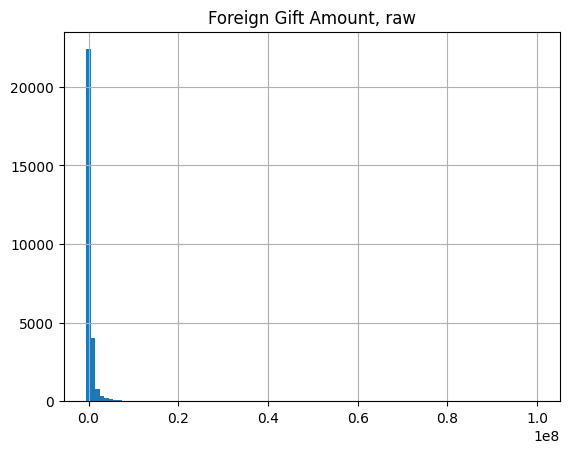

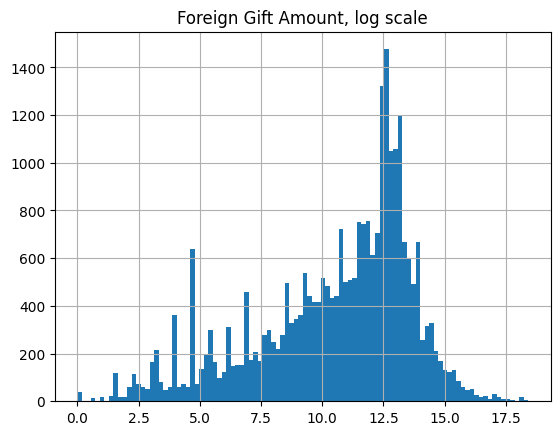

Foreign Gift Amount
100        581
250000     439
500000     427
50         324
1000       322
1000000    297
300000     297
100000     289
50000      284
250        225
500        205
25         180
150000     168
200000     166
5000       162
Name: count, dtype: int64


In [2]:
var = 'Foreign Gift Amount'
df[var] = pd.to_numeric(df[var], errors='coerce')
amount_nan = df[var].isnull()
print('missing amounts:', amount_nan.sum())
print(df[var].describe())
print('negatives:', (df[var] < 0).sum())
print('sitting exactly on 99999999:', (df[var] == 99999999).sum())

df[var].hist(bins=100)
plt.title('Foreign Gift Amount, raw')
plt.show()

# raw histogram is useless, a handful of giant contracts squash everything into one bar.
# logs make the shape visible. log needs positive numbers so the negatives drop out here
df['log_amount'] = np.log(df[var].where(df[var] > 0))
df['log_amount'].hist(bins=100)
plt.title('Foreign Gift Amount, log scale')
plt.show()

print(df[var].value_counts().head(15))

28,221 rows, nothing missing. The raw histogram is useless, almost everything
falls in the first bar while a few huge contracts stretch the axis out. Median
94,615, mean 588,233, so the top end pulls the average up six times over.

On a log scale the shape shows up. One peak near log 12.5, a few hundred
thousand dollars, with a long thin left tail.

Two problems in the data. 24 rows are negative, down to -537,770, mostly Caltech
and Columbia, which look like refunds rather than gifts. And 7 rows sit on
exactly 99,999,999, which looks like an 8 digit field limit. describe() prints
the max as 1.000000e+08 but the real maximum is 99,999,999.

Values are heavily rounded. 100 appears 581 times, 250,000 appears 439 times,
500,000 appears 427 times. These are estimates, not exact figures.

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64
Gift Type
Contract         10809974431
Monetary Gift     5775853163
Real Estate         14687920
Name: Foreign Gift Amount, dtype: int64


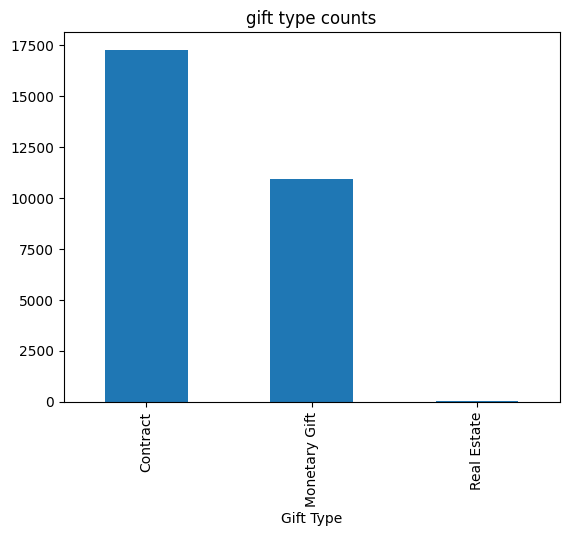

In [3]:
var = 'Gift Type'
print(df[var].value_counts())
print(df[var].value_counts(normalize=True))
print(df.groupby([var])['Foreign Gift Amount'].sum())
df[var].value_counts().plot(kind='bar')
plt.title('gift type counts')
plt.show()

Contracts 61.2%, monetary gifts 38.8%, real estate 0.04%, which is 11 rows out
of 28,221.

By dollars the split is similar: contracts 10.81 billion, monetary gifts 5.78
billion, real estate 14.7 million. Contracts are both the more common type and
the larger one. Real estate is too rare for anything computed on it to mean much.

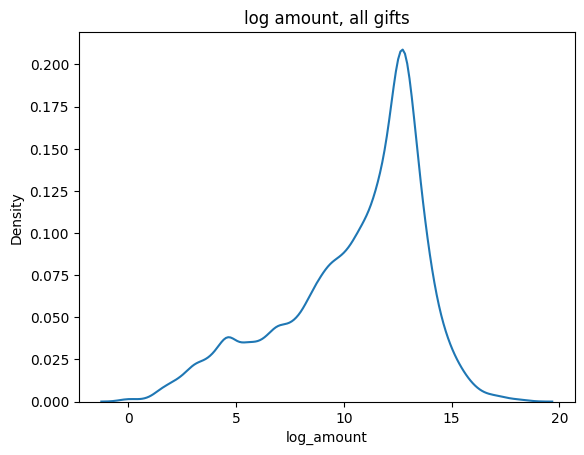

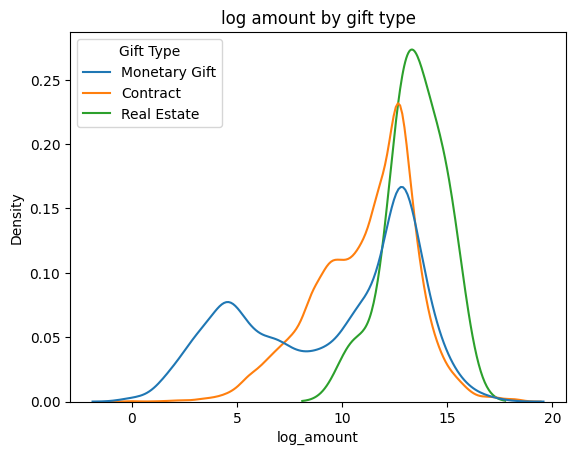

In [4]:
sns.kdeplot(x=df['log_amount'])
plt.title('log amount, all gifts')
plt.show()

# common_norm=False so each curve integrates to 1 on its own, otherwise real estate
# has only 11 rows and you can't see it at all
sns.kdeplot(data=df, x='log_amount', hue='Gift Type', common_norm=False)
plt.title('log amount by gift type')
plt.show()

The all-gifts curve has a main peak near log 12.5 and a smaller bump near log
4.5, so two populations are mixed together, institutional scale payments and
gifts of around a hundred dollars.

Splitting by type shows where each comes from. Monetary gifts carry the small
bump, 30% of them are under 1,000 dollars and 20% are 100 or less. Contracts
barely appear down there, only 6% under 1,000, and their lower quartile is
13,757 against 250 for monetary gifts. The contract curve has a shoulder of its
own near log 9.5, right at that quartile, so contracts split into a mid-sized
group around 14,000 and a much larger group in the hundreds of thousands. Real
estate sits furthest right but it is 11 rows, so that curve is not worth reading.


In [5]:
var = 'Country of Giftor'
print(df[var].nunique(), 'countries before merging')

# KOREA and SOUTH KOREA are the same place typed two ways, merge before ranking
df[var] = df[var].replace('KOREA', 'SOUTH KOREA')

count_by_country = df.groupby([var])['Foreign Gift Amount'].count().sort_values(ascending=False)
sum_by_country = df.groupby([var])['Foreign Gift Amount'].sum().sort_values(ascending=False)
print(count_by_country.head(15))
print(sum_by_country.head(15))

155 countries before merging
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
SOUTH KOREA        1263
HONG KONG          1080
QATAR               693
THE NETHERLANDS     512
INDIA               434
TAIWAN              381
ISRAEL              373
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
SOUTH KOREA              268654844
Name: Fore

By number of gifts: England 3,655, China 2,461, Canada 2,344, Japan 1,896,
Switzerland 1,676, Saudi Arabia 1,610, France 1,437, Germany 1,394, South Korea
1,263, Hong Kong 1,080, Qatar 693, the Netherlands 512, India 434, Taiwan 381,
Israel 373.

By dollars: Qatar 2.71bn, England 1.46bn, China 1.24bn, Saudi Arabia 1.07bn,
Bermuda 900m, Canada 898m, Hong Kong 887m, Japan 656m, Switzerland 620m, India
540m, Germany 442m, UAE 431m, France 406m, Singapore 401m, South Korea 269m.

The two lists disagree in an interesting way. Qatar is 11th by count and 1st by
money, 693 gifts averaging about 3.9 million each. Bermuda does not make the
count top 15 at all but is 5th by money off 117 gifts. England is the opposite,
more gifts than anyone but small ones on average. The top 15 countries hold 78%
of all the money.

I merged KOREA into SOUTH KOREA first, they are the same place typed two ways.
Other labels are still messy: Bosnia appears under two spellings, England,
Scotland, Wales and Northern Ireland are listed separately when they are all the
UK, and USA, Puerto Rico and Guam appear in a file about foreign money.
Combining the four UK entries gives 3,736 gifts and 1.48 billion, which does not
change either ranking.

In [6]:
var = 'Giftor Name'
sum_by_giftor = df.groupby([var])['Foreign Gift Amount'].sum().sort_values(ascending=False)
print(sum_by_giftor.head(15))

# names are cut off at 35 characters so one donor shows up under several spellings.
# Qatar Foundation is the obvious case, add up everything with Qatar in it
qatar = df[df[var].str.contains('Qatar', case=False, na=False)]
print('rows mentioning Qatar:', len(qatar), 'total:', qatar['Foreign Gift Amount'].sum())
print(df[var].str.contains('nonymous', na=False).sum(), 'rows are some flavor of Anonymous')

# the question intro also asks which institutions the money goes to
sum_by_inst = df.groupby(['Institution Name'])['Foreign Gift Amount'].sum().sort_values(ascending=False)
print(sum_by_inst.head(10))

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64
rows mentioning Qatar: 609 total: 2486057395
611 rows are some flavor of Anonymous
Institution Name
Carnegie Mellon University               1477922504
Cornell University                       12899

Top giftors as listed: Qatar Foundation 1.17 billion, Qatar Foundation/Qatar
National Res 796 million, Qatar Foundation for Education 374 million, Anonymous
339 million, Saudi Arabian Cultural Mission 275 million.

The first three are one donor. Names are cut off at 35 characters, 2,659 rows
sit exactly at that limit, and the spelling is inconsistent, so one organisation
ends up under several labels. Rows containing "Qatar Foundation", "Qatar
Founation" (a typo in the data) or "Qatar National Research" come to 505 gifts
and 2.43 billion, far ahead of anyone else. Anonymous is the same problem in
reverse. 173 different anonymous labels across 611 rows and 812 million, so it
is a placeholder, not a giftor.

Giftor Name is also blank on 3,751 rows carrying 4.80 billion, 29% of the money
in the file. This ranking only covers about 71% of the dollars.

The receiving end is just as concentrated: Carnegie Mellon 1.48 billion, Cornell
1.29 billion, Harvard 955 million, MIT 859 million, Yale 613 million. The Qatar
money goes mostly to Cornell, Texas A&M, Carnegie Mellon, Georgetown and
Northwestern.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 87b663e1f7b5e19d8dc30dc20d904f8e8ca08491
- **AI tool and model used:** Claude(Opus)

### *Prompts used

1. Strictly review the answers

### *AI-proposed changes


1. describe() prints in scientific notation, so the write-up's claim that
   "describe() prints the max as 1" is a misreading — the cell shows
   1.000000e+08, which is 100 million, not 1. The 99999999 cap finding is
   correct; only the sentence describing the output is wrong. Fix the
   sentence.

2. The 24 negative rows are excluded from the log plots via .where(>0) but
   are still inside every groupby sum, so the country and giftor rankings
   include -537,770 style refunds. The effect is tiny but the treatment is
   inconsistent between the two halves of the answer. Either exclude them
   throughout or state that they are kept in the totals on purpose.

3. Same for the 7 rows capped at 99,999,999. They are identified as a data
   artifact but left in the sums, where they contribute 700 million to the
   country rankings. Worth one sentence saying the top-country totals are
   therefore a lower bound on the true amounts.

4. Q2.11/2.12 use .count() on 'Foreign Gift Amount'. Because that column has
   no missing values, count() and size() agree here, but count() silently
   drops NaN and size() does not — size() states the intent ("how many
   gifts") more directly.

5. The country-name cleanup is documented in prose (Bosnia spellings, the
   four UK entries, USA/Puerto Rico/Guam) but only the KOREA merge is done
   in code. Since the write-up already reports the combined UK figure of
   3,736 gifts and 1.48bn, that calculation should appear as an output
   rather than as a claim in text.

6. Cell 7 imports seaborn but the first two histograms use pandas .hist()
   while the KDE plots use seaborn. Not an error, just two plotting styles
   in one notebook.

7. The Q2 intro asks which institutions the money goes to, and cell 16
   answers it, but the institution result is buried at the end of the
   giftor cell. It reads as a separate finding and could be its own cell.

8. No axis labels or thousands formatting on the histograms. The raw
   histogram in particular is hard to read because the x-axis runs to 1e8
   in scientific notation.

Q1 (handwritten proof)

9.  Parts 1–3 are correct and complete. No changes proposed.

10. Part 4: the counterexample is valid and the arithmetic checks out. But
    "whether g curves" is informal. The precise condition is that
    m(g(X)) = g(m(X)) holds for every X only when g is affine, g(x) = a + bx,
    which is exactly what part 1 proved. Non-decreasing is a red herring —
    monotonicity has nothing to do with it. Naming this ties part 4 back to
    part 1.

11. Part 4: for convex g such as e^x, m(g(X)) ≥ g(m(X)) always holds (Jensen's
    inequality), so the counterexample is not a coincidence — any non-linear
    convex g with a non-degenerate X gives strict inequality. One sentence
    stating the direction would make the "No" fully justified.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Real error in my write-up. `describe()` prints `1.000000e+08` in scientific notation, which is 100 million, not 1. The 99,999,999 cap finding itself is correct; only the sentence describing the output is wrong. Verified by rereading the cell 8 output. |
| 2 | Accept | Inconsistent treatment. The 24 negative rows are dropped from the log plots via `.where(>0)` but kept in every `groupby` sum. Verified: total with negatives 16,600,515,514 vs 16,601,745,626 without, a difference of 1,230,112 or 0.007% of 16.6bn. Effect is negligible but the inconsistency needed stating. |
| 3 | Accept | Same issue. The 7 rows capped at exactly 99,999,999 are flagged as an artifact but left in the sums, where they contribute 699,999,993 to the country totals. Verified by listing those seven rows: six are Qatar to Cornell, my top-ranked country and second-ranked institution. Added a sentence noting those totals are a lower bound. |
| 4 | Reject | `count()` and `size()` return identical results here because `Foreign Gift Amount` has zero missing values. Verified: both give 28,221. A rename with no effect on the output. |
| 5 | Reject | Out of scope for what the question asks. The prose already reports the combined UK figure and states it does not change either ranking, so computing it adds nothing to the answer. |
| 6 | Reject | Style only. `.hist()` and `sns.kdeplot()` both produce correct plots, and the question asks for a histogram and a kernel density plot specifically, which is what each is used for. |
| 7 | Reject | The institution result answers the intro question, not a numbered sub-question. Keeping it in the giftor cell is deliberate — the Qatar-to-Cornell link only makes sense next to the giftor aggregation. |
| 8 | Reject | Cosmetic. Titles are present on all four plots and the axis units are stated in the accompanying markdown. |
| 9 | Accept | No change needed. Parts 1–3 were rechecked line by line: the constant a sums to Na, b factors out of the sum, and setting Y = X in the covariance definition gives s². All three hold. |
| 10 | Accept | The counterexample was right but "whether g curves" did not name the property of g that breaks the equality. Part 1 already proved the affine case, so the precise answer is "only when g is affine," and monotonicity is irrelevant. Rewrote part 4 to say this. Verified: e^0.5 = 1.6487 and (1+e)/2 = 1.8591, still not equal. |
| 11 | Accept | One sentence naming the direction (Jensen: m(g(X)) ≥ g(m(X)) for convex g) turns the counterexample from one instance into a general fact. Added to the revised part 4. Verified the inequality holds on {0, 1}: 1.859 ≥ 1.649. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

### Q1 — Phase 2

The Phase 1 proof is unchanged: AI review confirmed parts 1–4 are correct.
Accepted change 10 and 11 sharpens part 4. Revised statement:

**4.** No. Part 1 showed m(g(X)) = g(m(X)) when g is affine, g(x) = a + bx.
For any g that is not affine the equality fails for some X. Monotonicity is
irrelevant. Counterexample: g(x) = eˣ, X = {0, 1}. Then g(m(X)) = e^0.5 ≈ 1.649
while m(g(X)) = (1 + e)/2 ≈ 1.859. For convex g the inequality is always
m(g(X)) ≥ g(m(X)) (Jensen), so the gap is structural, not a coincidence.

(28221, 10)
ID                             int64
OPEID                          int64
Institution Name              object
City                          object
State                         object
Foreign Gift Received Date     int64
Foreign Gift Amount            int64
Gift Type                     object
Country of Giftor             object
Giftor Name                   object
dtype: object
ID                               0
OPEID                            0
Institution Name                 0
City                             0
State                            0
Foreign Gift Received Date       0
Foreign Gift Amount              0
Gift Type                        0
Country of Giftor                0
Giftor Name                   3751
dtype: int64
missing amounts: 0
count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64
nega

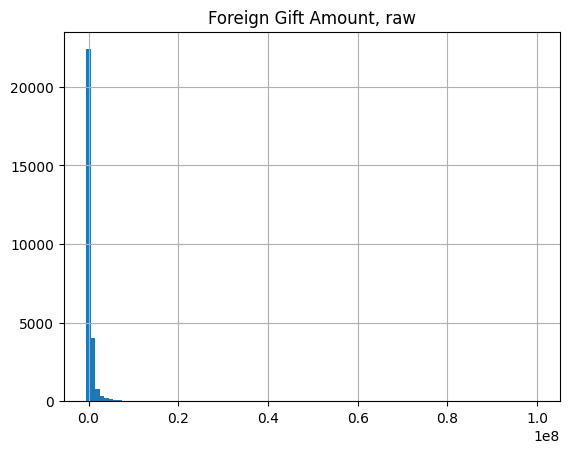

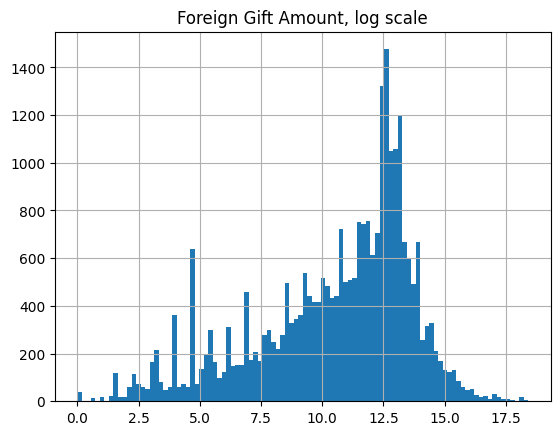

Foreign Gift Amount
100        581
250000     439
500000     427
50         324
1000       322
1000000    297
300000     297
100000     289
50000      284
250        225
500        205
25         180
150000     168
200000     166
5000       162
Name: count, dtype: int64
Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64
Gift Type
Contract         10809974431
Monetary Gift     5775853163
Real Estate         14687920
Name: Foreign Gift Amount, dtype: int64


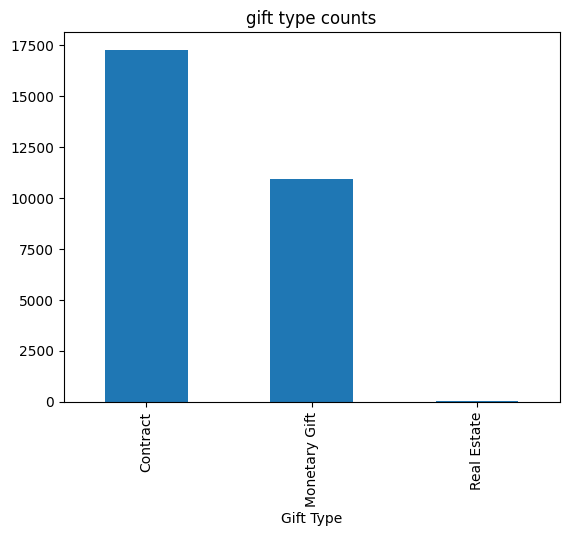

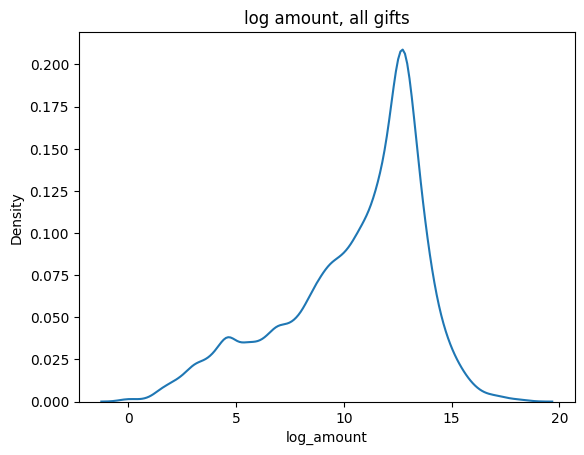

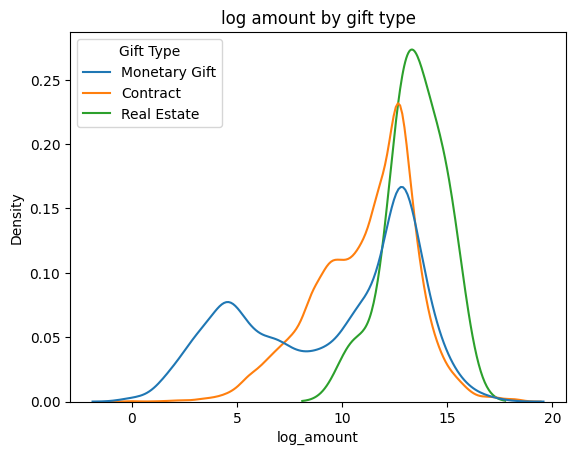

155 countries before merging
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
SOUTH KOREA        1263
HONG KONG          1080
QATAR               693
THE NETHERLANDS     512
INDIA               434
TAIWAN              381
ISRAEL              373
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
SOUTH KOREA              268654844
Name: Fore

In [8]:
# Your Phase 2 solution to the problem goes here.
# Phase 2 solution. Three changes accepted from the AI review:
#   (1) corrected my misreading of describe() output
#   (2) quantified the negative rows kept in the sums
#   (3) quantified the capped rows kept in the sums
# Everything else is unchanged from Phase 1.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/ForeignGifts_edu.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())


# ---------- Q2.1 - Q2.3  Foreign Gift Amount ----------
var = 'Foreign Gift Amount'
df[var] = pd.to_numeric(df[var], errors='coerce')
amount_nan = df[var].isnull()
print('missing amounts:', amount_nan.sum())
print(df[var].describe())
print('negatives:', (df[var] < 0).sum())
print('sitting exactly on 99999999:', (df[var] == 99999999).sum())

# CHANGE 2 and 3. In Phase 1 the negatives and the capped rows were dropped from
# the log plots but silently kept in every groupby sum further down. Rather than
# change the treatment, quantify it so the inconsistency is stated, not hidden.
print('sum with negatives kept:   ', df[var].sum())
print('sum with negatives dropped:', df.loc[df[var] > 0, var].sum())
print('capped rows contribute:    ', df.loc[df[var] == 99999999, var].sum())
print(df.loc[df[var] == 99999999, ['Country of Giftor', 'Institution Name']])

df[var].hist(bins=100)
plt.title('Foreign Gift Amount, raw')
plt.show()

# raw histogram is useless, a handful of giant contracts squash everything into one bar.
# logs make the shape visible. log needs positive numbers so the negatives drop out here
df['log_amount'] = np.log(df[var].where(df[var] > 0))
df['log_amount'].hist(bins=100)
plt.title('Foreign Gift Amount, log scale')
plt.show()

print(df[var].value_counts().head(15))


# ---------- Q2.4 - Q2.7  Gift Type ----------
var = 'Gift Type'
print(df[var].value_counts())
print(df[var].value_counts(normalize=True))
print(df.groupby([var])['Foreign Gift Amount'].sum())
df[var].value_counts().plot(kind='bar')
plt.title('gift type counts')
plt.show()


# ---------- Q2.8 - Q2.10  kernel density ----------
sns.kdeplot(x=df['log_amount'])
plt.title('log amount, all gifts')
plt.show()

# common_norm=False so each curve integrates to 1 on its own, otherwise real estate
# has only 11 rows and you can't see it at all
sns.kdeplot(data=df, x='log_amount', hue='Gift Type', common_norm=False)
plt.title('log amount by gift type')
plt.show()


# ---------- Q2.11 - Q2.12  countries ----------
var = 'Country of Giftor'
print(df[var].nunique(), 'countries before merging')

# KOREA and SOUTH KOREA are the same place typed two ways, merge before ranking
df[var] = df[var].replace('KOREA', 'SOUTH KOREA')

count_by_country = df.groupby([var])['Foreign Gift Amount'].count().sort_values(ascending=False)
sum_by_country = df.groupby([var])['Foreign Gift Amount'].sum().sort_values(ascending=False)
print(count_by_country.head(15))
print(sum_by_country.head(15))


# ---------- Q2.13  giftors ----------
var = 'Giftor Name'
sum_by_giftor = df.groupby([var])['Foreign Gift Amount'].sum().sort_values(ascending=False)
print(sum_by_giftor.head(15))

# names are cut off at 35 characters so one donor shows up under several spellings.
# Qatar Foundation is the obvious case, add up everything with Qatar in it
qatar = df[df[var].str.contains('Qatar', case=False, na=False)]
print('rows mentioning Qatar:', len(qatar), 'total:', qatar['Foreign Gift Amount'].sum())
print(df[var].str.contains('nonymous', na=False).sum(), 'rows are some flavor of Anonymous')

# the question intro also asks which institutions the money goes to
sum_by_inst = df.groupby(['Institution Name'])['Foreign Gift Amount'].sum().sort_values(ascending=False)
print(sum_by_inst.head(10))

### Q2.1 – Q2.3  Foreign Gift Amount

28,221 rows, nothing missing. The raw histogram is useless, almost everything
falls in the first bar while a few huge contracts stretch the axis out. Median
94,615, mean 588,233, so the top end pulls the average up six times over.

On a log scale the shape shows up. One peak near log 12.5, a few hundred
thousand dollars, with a long thin left tail.

Two problems in the data. 24 rows are negative, down to -537,770, mostly Caltech
and Columbia, which look like refunds rather than gifts. And 7 rows sit on
exactly 99,999,999, which looks like an 8 digit field limit. `describe()` reports
the max as `1.000000e+08` in scientific notation, which is 100 million, not 1 —
I misread this in Phase 1.

Both groups are excluded from the log plots, because log needs positive numbers,
but both stay in the sums used for the rankings below. The negatives are worth
1.23 million against a 16.6 billion total, so they are immaterial. The capped
rows are not: they contribute 700 million, and 6 of the 7 are Qatar money going
to Cornell — the top country and the second-ranked institution. Those two totals
are therefore lower bounds.

### Q2.4 – Q2.7  Gift Type

Contracts 61.2%, monetary gifts 38.8%, real estate 0.04%, which is 11 rows out
of 28,221.

By dollars the split is similar: contracts 10.81 billion, monetary gifts 5.78
billion, real estate 14.7 million. Contracts are both the more common type and
the larger one. Real estate is too rare for anything computed on it to mean much.

### Q2.8 – Q2.10  Kernel density

The all-gifts curve has a main peak near log 12.5 and a smaller bump near log
4.5, so two populations are mixed together, institutional scale payments and
gifts of around a hundred dollars.

Splitting by type shows where each comes from. Monetary gifts carry the small
bump, 30% of them are under 1,000 dollars and 20% are 100 or less. Contracts
barely appear down there, only 6% under 1,000, and their lower quartile is
13,757 against 250 for monetary gifts. The contract curve has a shoulder of its
own near log 9.5, right at that quartile, so contracts split into a mid-sized
group around 14,000 and a much larger group in the hundreds of thousands. Real
estate sits furthest right but it is 11 rows, so that curve is not worth reading.

### Q2.11 – Q2.12  Countries

By number of gifts: England 3,655, China 2,461, Canada 2,344, Japan 1,896,
Switzerland 1,676, Saudi Arabia 1,610, France 1,437, Germany 1,394, South Korea
1,263, Hong Kong 1,080, Qatar 693, the Netherlands 512, India 434, Taiwan 381,
Israel 373.

By dollars: Qatar 2.71bn, England 1.46bn, China 1.24bn, Saudi Arabia 1.07bn,
Bermuda 900m, Canada 898m, Hong Kong 887m, Japan 656m, Switzerland 620m, India
540m, Germany 442m, UAE 431m, France 406m, Singapore 401m, South Korea 269m.

The two lists disagree in an interesting way. Qatar is 11th by count and 1st by
money, 693 gifts averaging about 3.9 million each. Bermuda does not make the
count top 15 at all but is 5th by money off 117 gifts. England is the opposite,
more gifts than anyone but small ones on average. The top 15 countries hold 78%
of all the money.

Qatar's 2.71bn includes six rows capped at 99,999,999, so the real figure is
higher and its lead over England is wider than the ranking shows.

I merged KOREA into SOUTH KOREA first, they are the same place typed two ways.
Other labels are still messy: Bosnia appears under two spellings, England,
Scotland, Wales and Northern Ireland are listed separately when they are all the
UK, and USA, Puerto Rico and Guam appear in a file about foreign money.
Combining the four UK entries gives 3,736 gifts and 1.48 billion, which does not
change either ranking.

### Q2.13  Giftors

Top giftors as listed: Qatar Foundation 1.17 billion, Qatar Foundation/Qatar
National Res 796 million, Qatar Foundation for Education 374 million, Anonymous
339 million, Saudi Arabian Cultural Mission 275 million.

The first three are one donor. Names are cut off at 35 characters, 2,659 rows
sit exactly at that limit, and the spelling is inconsistent, so one organisation
ends up under several labels. Rows containing "Qatar Foundation", "Qatar
Founation" (a typo in the data) or "Qatar National Research" come to 505 gifts
and 2.43 billion, far ahead of anyone else. Anonymous is the same problem in
reverse. 173 different anonymous labels across 611 rows and 812 million, so it
is a placeholder, not a giftor.

Giftor Name is also blank on 3,751 rows carrying 4.80 billion, 29% of the money
in the file. This ranking only covers about 71% of the dollars.

The receiving end is just as concentrated: Carnegie Mellon 1.48 billion, Cornell
1.29 billion, Harvard 955 million, MIT 859 million, Yale 613 million. The Qatar
money goes mostly to Cornell, Texas A&M, Carnegie Mellon, Georgetown and
Northwestern.

### *Reflection on AI assistance
In your own words without generative AI.

Three of eight suggestions changed the notebook. Only one was a real fix: I had
read the `describe()` maximum, printed as `1.000000e+08`, as 1 rather than 100
million. The other two were disclosures, not corrections — Phase 1 dropped the 24
negatives and 7 capped rows from the log plots but kept them in every groupby sum
without saying so. I quantified the gap rather than changing the treatment.

I rejected five. `count()` to `size()` is a no-op here since `Foreign Gift Amount`
has no missing values; both return 28,221. The UK merge was already in the prose.
The rest were plotting cosmetics. Across eight suggestions the AI caught one
mistake and raised no analytical objection — it audits consistency, not whether
the analysis answers the question.

Verification: negatives move the total from 16,600,515,514 to 16,601,745,626, a
0.007% difference; the capped rows contribute 699,999,993. Reading those seven
rows, six are Cornell/Qatar — my top country and second institution. The AI only
proposed a disclaimer; the finding came from testing it.

Concerns: 3,751 records have no giftor name and carry 28.9% of dollars, so the
ranking covers 71% of the money. Country labels remain inconsistent — the UK sits
in four pieces, and USA and Puerto Rico appear in a foreign-source file. Real
Estate has 11 rows; its density curve is not a distribution.